# Đồ án cuối kỳ — RNN (LSTM/GRU) và CNN cho phát hiện ransomware trên BitcoinHeist

**Bài toán:** từ các đặc trưng giao dịch của một địa chỉ Bitcoin trong một ngày, dự đoán địa chỉ là `white` hay thuộc họ
ransomware nào → **phân loại 7 lớp**, dữ liệu bảng, mất cân bằng nặng (white 98,6%).

**Ý tưởng chính:** dữ liệu là bảng nên thử **hai cách biểu diễn chuỗi**:
- **A — feature-as-sequence:** 11 đặc trưng của một dòng = chuỗi 11 bước (chia ngẫu nhiên, giống Bài 1).
- **B — address history:** lịch sử ≤ 16 lần xuất hiện gần nhất của cùng địa chỉ = chuỗi thời gian thật (chia theo địa chỉ).

**Mã nguồn** nằm trong gói `final/`: `data.py` (đọc, tiền xử lý, chia, dựng chuỗi), `models.py` (LSTM/GRU, CNN1D, MLP),
`configs.py` (các cấu hình thực nghiệm), `train.py` (huấn luyện + đánh giá), `baselines.py` (XGBoost), `benchmark.py`
(đo tốc độ), `report.py` (bảng + hình). Huấn luyện thật chạy trên GPU (máy Trainbox) bằng
`python -m final.train --rep A` / `--rep B`; notebook này mặc định **nạp kết quả đã lưu** trong `outputs/final/`
(đặt `RETRAIN = True` để huấn luyện lại từ đầu một vài cấu hình ngay trong notebook).

**Nội dung**
1. Đọc & mô tả dữ liệu
2. Tiền xử lý & chia dữ liệu
3. Biểu diễn chuỗi A và B
4. Kiến trúc mô hình
5. Huấn luyện
6. Kết quả biểu diễn A (RNN, CNN, so với baseline)
7. Kết quả biểu diễn B và các thí nghiệm đối chứng
8. Đường cong huấn luyện — overfitting / underfitting
9. Ma trận nhầm lẫn, F1 từng lớp
10. Phân tích lỗi & minh hoạ dự đoán
11. Kết luận

In [1]:
import json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Image

from final import data, models, configs, train, report

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 60)
RETRAIN = False                  # True: huấn luyện lại RETRAIN_CONFIGS ngay trong notebook (ghi đè outputs/final)
RETRAIN_CONFIGS = ["A_gru", "A_cnn_bn_do"]
OUT, FIG = train.OUT, report.FIG
print("torch", torch.__version__, "| device", train.DEV)

torch 2.14.1 | device cpu


## 1. Đọc & mô tả dữ liệu

In [2]:
df, CLASSES = data.load_frame()
print(f"{len(df):,} dòng, {df['address'].nunique():,} địa chỉ, năm {df['year'].min()}–{df['year'].max()}")
print("Giá trị thiếu:", int(df.isna().sum().sum()), "| dòng trùng (address, year, day):",
      int(df.duplicated(['address', 'year', 'day']).sum()))
df.head()

2,916,697 dòng, 2,631,095 địa chỉ, năm 2011–2018


Giá trị thiếu: 0 | dòng trùng (address, year, day): 0


,address,year,day,length,weight,count,looped,neighbors,income,label,target,y,month,weekday,t,income_tz,income_per_count,income_per_neighbor,weight_per_count,looped_ratio
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.0083,1,0,2,100050000.0000,princetonCerber,princetonCerber,4,1,2,2202,4,100050000.0000,50025000.0000,0.0083,0.0000
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.0002,1,0,1,100000000.0000,princetonLocky,princetonLocky,5,5,2,1957,8,100000000.0000,100000000.0000,0.0002,0.0000
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.0000,1,0,2,200000000.0000,princetonCerber,princetonCerber,4,9,4,2071,8,200000000.0000,100000000.0000,1.0000,0.0000
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.0039,1,0,2,71200000.0000,princetonCerber,princetonCerber,4,11,3,2147,5,71200000.0000,35600000.0000,0.0039,0.0000
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.0728,456,0,1,200000000.0000,princetonLocky,princetonLocky,5,8,3,2063,8,438596.4912,200000000.0000,0.0002,0.0000


In [3]:
vc = df["target"].value_counts()
display(pd.DataFrame({"số dòng": vc, "tỉ lệ %": 100 * vc / len(df)}))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
vc.plot.bar(ax=ax[0], logy=True, title="Phân bố 7 lớp (thang log)", color="#4C72B0")
ct = pd.crosstab(df["year"], df["target"] != "white").rename(columns={False: "white", True: "ransomware"})
(100 * ct["ransomware"] / ct.sum(1)).plot.bar(ax=ax[1], title="% dòng ransomware theo năm", color="#DD8452")
plt.tight_layout(); plt.show()

,số dòng,tỉ lệ %
target,,
white,2875284,98.5801
paduaCryptoWall,12390,0.4248
montrealCryptoLocker,9315,0.3194
princetonCerber,9223,0.3162
princetonLocky,6625,0.2271
montrealCryptXXX,2419,0.0829
otherRansom,1441,0.0494


**Nhận xét:** white chiếm 98,6% → accuracy vô nghĩa (đoán toàn white = 98,6%), dùng **macro F1** làm độ đo chính.
Tỉ lệ ransomware thay đổi mạnh theo năm → giữ year/month/weekday làm đầu vào (one-hot).

In [4]:
# Địa chỉ có xuất hiện lại ở các ngày khác không? → cơ sở của biểu diễn B
hist16, gap, n_prev = data.address_history(df, 16)
df["n_prev"] = n_prev
rep = df.groupby("target").agg(so_dong=("y", "size"), so_dia_chi=("address", "nunique"),
                               lan_dau_pct=("n_prev", lambda s: 100 * (s == 0).mean()),
                               trung_vi_so_lan_truoc=("n_prev", "median"), tb_so_lan_truoc=("n_prev", "mean"))
display(rep.sort_values("so_dong", ascending=False))

,so_dong,so_dia_chi,lan_dau_pct,trung_vi_so_lan_truoc,tb_so_lan_truoc
target,,,,,
white,2875284,2610246,90.7822,0.0000,0.5473
paduaCryptoWall,12390,1894,15.2865,5.0000,11.9985
montrealCryptoLocker,9315,1509,16.1997,13.0000,36.8554
princetonCerber,9223,9177,99.5012,0.0000,0.0053
princetonLocky,6625,6584,99.3811,0.0000,0.0071
montrealCryptXXX,2419,1354,55.9735,0.0000,0.8867
otherRansom,1441,331,22.9702,6.0000,17.0562


**Nhận xét quan trọng:** `CryptoLocker`, `CryptoWall`, `otherRansom` **dùng lại địa chỉ** rất nhiều (chỉ 15–23% dòng là lần
đầu xuất hiện), còn `Cerber`, `Locky` gần như luôn dùng địa chỉ mới (99,5%), giống `white` (90,8%).
Đây đúng là 2 lớp khó nhất ở Bài 1 (F1 ≈ 0,28 / 0,41) → **lịch sử của địa chỉ** có thể giúp phân biệt chúng.

## 2. Tiền xử lý & chia dữ liệu

- Nhãn: 5 họ phổ biến nhất + `otherRansom` + `white`. Đặc trưng: 6 gốc + 5 mới (`income_tz`, các tỉ lệ) → 11 số;
  `year/month/weekday` → one-hot 27 chiều.
- Số: `log1p` → chuẩn hoá (μ, σ **chỉ tính trên train**).
- Chia 64/16/20: **ngẫu nhiên phân tầng** (biểu diễn A, như Bài 1) hoặc **theo địa chỉ** (biểu diễn B).
- Train: undersample còn 100k white + toàn bộ ransomware; sau huấn luyện tìm trọng số lớp `w` trên validation.
- `val_us`: validation undersample cùng tỉ lệ white với train → đường cong train/val so sánh được, dùng cho early stopping.

In [5]:
prepA = data.prepare("random")
prepB = data.prepare("group", history_len=32)
for name, p in [("A — chia ngẫu nhiên", prepA), ("B — chia theo địa chỉ", prepB)]:
    sizes = {k: len(v) for k, v in p.idx.items()}
    ransom = {k: int((p.y[v] != p.white).sum()) for k, v in p.idx.items()}
    display(pd.DataFrame({"số dòng": sizes, "ransomware": ransom}).T.rename_axis(name))
addr = df["address"].to_numpy()
print("Số địa chỉ chung giữa train và test (chia theo địa chỉ):",
      len(set(addr[np.r_[prepB.idx['fit']]]) & set(addr[prepB.idx['test']])))
print("Kiểm tra chuẩn hoá trên tập fit: mean ≈ 0, std ≈ 1 →",
      prepA.num[prepA.idx['fit']].mean(0).round(3).max(), prepA.num[prepA.idx['fit']].std(0).round(3).min())

,fit,val,val_us,test
A — chia ngẫu nhiên,,,,
số dòng,126504,466672,31626,583340
ransomware,26504,6626,6626,8283


,fit,val,val_us,test
B — chia theo địa chỉ,,,,
số dòng,126853,466842,31657,582810
ransomware,26853,6649,6649,7911


Số địa chỉ chung giữa train và test (chia theo địa chỉ): 0
Kiểm tra chuẩn hoá trên tập fit: mean ≈ 0, std ≈ 1 → 0.0 0.999


## 3. Biểu diễn chuỗi

**A — feature-as-sequence:** một dòng → chuỗi 11 bước; bước *i* là giá trị chuẩn hoá của đặc trưng *i*, được nhúng thành
vector 16 chiều bằng `x_i·W_i + b_i` (W_i, b_i riêng cho từng đặc trưng). Độ dài cố định, không cần đệm.
*Hạn chế:* thứ tự đặc trưng do ta đặt, không có ý nghĩa thời gian.

In [6]:
i = prepA.idx["test"][np.flatnonzero(prepA.y[prepA.idx["test"]] == CLASSES.index("princetonLocky"))[0]]
display(pd.DataFrame({"đặc trưng (bước)": data.NUM, "giá trị gốc": df.loc[i, data.NUM].to_numpy(),
                      "sau log1p + chuẩn hoá": prepA.num[i]}).T)

,0,1,2,3,4,5,6,7,8,9,10
đặc trưng (bước),length,weight,count,looped,neighbors,income,income_tz,income_per_count,income_per_neighbor,weight_per_count,looped_ratio
giá trị gốc,6,0.0006,1,0,1,99990000.0000,4,99990000.0000,99990000.0000,0.0006,0.0000
sau log1p + chuẩn hoá,-0.2538,-0.9298,-0.6541,-0.3357,-0.9762,-0.5927,0.6091,0.3159,-0.2850,-0.8557,-0.3625


**B — address history:** với dòng (địa chỉ *a*, ngày *t*) lấy tối đa *L* lần xuất hiện gần nhất của *a* tại các ngày ≤ *t*,
theo thời gian; bước cuối = dòng hiện tại. Mỗi bước 13 chiều (11 đặc trưng + cờ "lần đầu" + log(1+Δngày)).
Chuỗi dài ngắn khác nhau → đệm 0 ở cuối + mask (`pack_padded_sequence` cho RNN, pooling có mask cho CNN).

In [7]:
cl = CLASSES.index("montrealCryptoLocker")
cand = prepB.idx["test"][(prepB.y[prepB.idx["test"]] == cl)]
r = cand[np.argmax((prepB.hist[cand] >= 0).sum(1) >= 6)]
h = prepB.hist[r][prepB.hist[r] >= 0][-8:]
ex = df.loc[h, ["address", "year", "day", "income", "length", "count", "neighbors", "target"]].copy()
ex["Δngày"] = np.where(prepB.gap[h] < 0, np.nan, prepB.gap[h])
print("Lịch sử (8 bước cuối) của một địa chỉ CryptoLocker trong tập test — dòng cuối là ngày cần dự đoán:")
display(ex)
L = (prepB.hist >= 0).sum(1)
pd.crosstab(df["target"], np.minimum(L, 16), normalize="index").mul(100).round(1).iloc[:, [0, 1, 2, 4, 9, 15]] \
  .rename(columns=lambda c: f"L={c}" if c < 16 else "L≥16")

Lịch sử (8 bước cuối) của một địa chỉ CryptoLocker trong tập test — dòng cuối là ngày cần dự đoán:


,address,year,day,income,length,count,neighbors,target,Δngày
802,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,222,1700000000.0000,0,1,2,montrealCryptoLocker,NaN
804,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,255,3666000000.0000,2,1,4,montrealCryptoLocker,33.0000
805,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,298,60000000.0000,0,1,2,montrealCryptoLocker,43.0000
808,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,301,50000000.0000,0,1,2,montrealCryptoLocker,3.0000
809,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,305,50000000.0000,0,1,2,montrealCryptoLocker,4.0000
806,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,306,50000000.0000,2,1,2,montrealCryptoLocker,1.0000
807,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,307,120000000.0000,144,623,4,montrealCryptoLocker,1.0000
803,12iuN2CtinxqxNh3aZZPUyChv5u5orHMLG,2013,308,70000000.0000,14,9,2,montrealCryptoLocker,1.0000


col_0,L=1,L=2,L=3,L=5,L=10,L≥16
target,,,,,,
montrealCryptXXX,56.0000,24.1000,10.8000,2.1000,0.1000,0.3000
montrealCryptoLocker,16.2000,4.8000,4.0000,3.3000,2.0000,48.3000
otherRansom,23.0000,6.9000,5.0000,4.0000,2.4000,32.4000
paduaCryptoWall,15.3000,10.8000,8.4000,5.8000,2.8000,24.2000
princetonCerber,99.5000,0.5000,0.0000,0.0000,0.0000,0.0000
princetonLocky,99.4000,0.5000,0.1000,0.0000,0.0000,0.0000
white,90.8000,3.3000,1.4000,0.6000,0.2000,1.0000


## 4. Kiến trúc mô hình

In [8]:
def show_model(name, prep):
    cfg = configs.ALL[name]
    b = train.Batcher(prep, cfg["rep"], cfg["train"].get("history_len"), cfg["train"].get("side_count", False))
    m = models.build(cfg, b.in_dim, b.side.shape[1], len(CLASSES), b.seq_len)
    print(f"===== {name}: {models.n_params(m):,} tham số | train: {cfg['train']}")
    print(m)

for n in ["A_lstm", "A_cnn_bn_do"]:
    show_model(n, prepA)
for n in ["B_gru", "B_cnn_bn_do"]:
    show_model(n, prepB)

===== A_lstm: 27,687 tham số | train: {'lr': 0.001, 'batch_size': 512, 'max_epochs': 100, 'patience': 10, 'weight_decay': 0.0, 'seed': 42}
RNNNet(
  (embed): FeatureTokenizer()
  (rnn): LSTM(16, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=91, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)
===== A_cnn_bn_do: 22,855 tham số | train: {'lr': 0.001, 'batch_size': 512, 'max_epochs': 100, 'patience': 10, 'weight_decay': 0.0, 'seed': 42}
CNNNet(
  (embed): FeatureTokenizer()
  (blocks): ModuleList(
    (0): ModuleDict(
      (conv): Sequential(
        (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
      )
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

===== B_gru: 25,607 tham số | train: {'lr': 0.001, 'batch_size': 512, 'max_epochs': 100, 'patience': 10, 'weight_decay': 0.0, 'seed': 42, 'history_len': 16}
RNNNet(
  (embed): Linear(in_features=13, out_features=32, bias=True)
  (rnn): GRU(32, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=91, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)


===== B_cnn_bn_do: 16,295 tham số | train: {'lr': 0.001, 'batch_size': 512, 'max_epochs': 100, 'patience': 10, 'weight_decay': 0.0, 'seed': 42, 'history_len': 16}
CNNNet(
  (embed): Linear(in_features=13, out_features=32, bias=True)
  (blocks): ModuleList(
    (0): ModuleDict(
      (conv): Sequential(
        (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
      )
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    )
    (1): ModuleDict(
      (conv): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
      )
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0,

In [9]:
rows = []
for c in configs.A + configs.B:
    rows.append({"cấu hình": c["name"], "biểu diễn": c["rep"], "loại": c["model"],
                 "kiến trúc": report.describe({**c, "config": c["name"]}),
                 "lr": c["train"]["lr"], "batch": c["train"]["batch_size"], "L": c["train"].get("history_len", "-")})
pd.DataFrame(rows)

,cấu hình,biểu diễn,loại,kiến trúc,lr,batch,L
0,A_lstm,A,rnn,"LSTM 1x64, last",0.0010,512,-
1,A_gru,A,rnn,"GRU 1x64, last",0.0010,512,-
2,A_lstm_2l,A,rnn,"LSTM 2x64, last",0.0010,512,-
3,A_gru_2l,A,rnn,"GRU 2x64, last",0.0010,512,-
4,A_gru_h128,A,rnn,"GRU 1x128, last",0.0010,512,-
5,A_bigru,A,rnn,"BiGRU 1x64, last",0.0010,512,-
6,A_gru_mean,A,rnn,"GRU 1x64, mean",0.0010,512,-
7,A_gru_attn,A,rnn,"GRU 1x64, attn",0.0010,512,-
8,A_gru_nodrop,A,rnn,"GRU 1x64, last, do 0.0",0.0010,512,-
9,A_gru_lr3e-4,A,rnn,"GRU 1x64, last",0.0003,512,-


**Các thành phần chung:** đầu ra Dense 7 + softmax; hàm mất mát cross-entropy; Adam (lr 1e-3), batch 512, tối đa 100 epoch,
early stopping theo macro F1 trên `val_us` (patience 10), cắt gradient ≤ 1. RNN: dropout 0,2 ở lớp Dense cuối và giữa các
tầng khi có 2 tầng (không dùng recurrent dropout — cuDNN không hỗ trợ). CNN: Conv1D + (BN) + ReLU + (Dropout 0,3) + MaxPool 2,
rồi Flatten (A) hoặc Global Average/Max Pooling có mask (B).

## 5. Huấn luyện

In [10]:
if RETRAIN:
    for n in RETRAIN_CONFIGS:
        train.run(configs.ALL[n], prepA if configs.ALL[n]["rep"] == "A" else prepB,
                  "random" if configs.ALL[n]["rep"] == "A" else "group")
res = report.load_results()
summ = report.summary_table(res)
print(f"Đã nạp {len(res)} lần chạy, {len(summ)} cấu hình")
bench = json.load(open(OUT / "benchmark.json")) if (OUT / "benchmark.json").exists() else {}

Đã nạp 81 lần chạy, 49 cấu hình


## 6. Kết quả biểu diễn A (chia ngẫu nhiên)

In [11]:
cols = ["config", "arch", "lr", "batch_size", "n_params", "best_epoch", "epochs", "macro_f1", "macro_f1_std", "n_seeds",
        "binary_f1", "accuracy", "weighted_f1"]
A = summ[summ["group"] == "A_random"]
print("RNN"); display(A[A["model"] == "rnn"][cols])
print("CNN"); display(A[A["model"] == "cnn"][cols])
print("MLP"); display(A[A["model"] == "mlp"][cols])

RNN


,config,arch,lr,batch_size,n_params,best_epoch,epochs,macro_f1,macro_f1_std,n_seeds,binary_f1,accuracy,weighted_f1
4,A_bigru,"BiGRU 1x64, last",0.0010,512.0000,42279.0000,30.0000,40.0000,0.5365,0.0037,3,0.4675,0.9833,0.9840
5,A_gru_2l,"GRU 2x64, last",0.0010,512.0000,47399.0000,49.0000,59.0000,0.5358,0.0073,3,0.4614,0.9829,0.9838
6,A_lstm_2l,"LSTM 2x64, last",0.0010,512.0000,60967.0000,49.0000,59.0000,0.5350,0.0024,3,0.4631,0.9830,0.9839
7,A_lstm,"LSTM 1x64, last",0.0010,512.0000,27687.0000,50.0000,60.0000,0.5329,0.0032,3,0.4619,0.9821,0.9833
8,A_gru_attn,"GRU 1x64, attn",0.0010,512.0000,22504.0000,47.0000,57.0000,0.5320,NaN,1,0.4743,0.9842,0.9844
9,A_gru_mean,"GRU 1x64, mean",0.0010,512.0000,22439.0000,42.0000,52.0000,0.5305,NaN,1,0.4607,0.9838,0.9841
11,A_gru_h128,"GRU 1x128, last",0.0010,512.0000,66855.0000,35.0000,45.0000,0.5268,NaN,1,0.4645,0.9832,0.9838
13,A_gru_bs2048,"GRU 1x64, last",0.0010,2048.0000,22439.0000,98.0000,100.0000,0.5254,NaN,1,0.4625,0.9837,0.9841
14,A_gru_nodrop,"GRU 1x64, last, do 0.0",0.0010,512.0000,22439.0000,63.0000,73.0000,0.5245,NaN,1,0.4550,0.9834,0.9839
15,A_gru,"GRU 1x64, last",0.0010,512.0000,22439.0000,42.0000,52.0000,0.5237,0.0040,3,0.4606,0.9836,0.9840


CNN


,config,arch,lr,batch_size,n_params,best_epoch,epochs,macro_f1,macro_f1_std,n_seeds,binary_f1,accuracy,weighted_f1
10,A_cnn_bn,"Conv 32-64 k3 maxpool +BN, flatten, do 0.0",0.0010,512.0000,22855.0000,53.0000,63.0000,0.5276,NaN,1,0.4448,0.9813,0.9828
12,A_cnn_wide,"Conv 64-128 k3 maxpool +BN, flatten, do 0.3",0.0010,512.0000,55399.0000,42.0000,52.0000,0.5267,NaN,1,0.4538,0.9838,0.9840
16,A_cnn_simple,"Conv 32-64 k3 maxpool, flatten, do 0.0",0.0010,512.0000,22663.0000,47.0000,57.0000,0.5235,0.0050,3,0.4513,0.9830,0.9836
18,A_cnn_3l,"Conv 32-64-128 k3 maxpool +BN, flatten, do 0.3",0.0010,512.0000,60103.0000,42.0000,52.0000,0.5219,NaN,1,0.4554,0.9830,0.9836
19,A_cnn_do,"Conv 32-64 k3 maxpool, flatten, do 0.3",0.0010,512.0000,22663.0000,42.0000,52.0000,0.5199,NaN,1,0.4544,0.9842,0.9842
20,A_cnn_avgpool,"Conv 32-64 k3 avgpool +BN, flatten, do 0.3",0.0010,512.0000,22855.0000,42.0000,52.0000,0.5199,NaN,1,0.4512,0.9821,0.9831
21,A_cnn_k5,"Conv 32-64 k5 maxpool +BN, flatten, do 0.3",0.0010,512.0000,27975.0000,42.0000,52.0000,0.5188,NaN,1,0.4496,0.9823,0.9832
22,A_cnn_bs2048,"Conv 32-64 k3 maxpool +BN, flatten, do 0.3",0.0010,2048.0000,22855.0000,73.0000,83.0000,0.5154,NaN,1,0.4387,0.9819,0.9829
23,A_cnn_bn_do,"Conv 32-64 k3 maxpool +BN, flatten, do 0.3",0.0010,512.0000,22855.0000,42.0000,52.0000,0.5141,0.0033,3,0.4424,0.9822,0.9831
24,A_cnn_gap,"Conv 32-64 k3 maxpool +BN, gap, do 0.3",0.0010,512.0000,14663.0000,45.0000,55.0000,0.5129,NaN,1,0.4427,0.9819,0.9829


MLP


,config,arch,lr,batch_size,n_params,best_epoch,epochs,macro_f1,macro_f1_std,n_seeds,binary_f1,accuracy,weighted_f1
17,A_mlp,"MLP 2x128, do 0.2",0.0010,512.0000,22407.0000,42.0000,52.0000,0.5227,0.0063,3,0.4521,0.9821,0.9832


In [12]:
# So sánh với mô hình nền của Bài 1 (cùng cách chia ngẫu nhiên, cùng tiền xử lý & hiệu chỉnh trọng số lớp)
b1 = report.bai1_baselines().assign(nguồn="Bài 1")
best = lambda m: A[A["model"] == m].iloc[0]
nn_rows = pd.DataFrame([{"model": f"{best(m)['config']} ({m.upper()})", "macro_f1": best(m)["macro_f1"],
                         "binary_f1": best(m)["binary_f1"], "accuracy": best(m)["accuracy"],
                         "weighted_f1": best(m)["weighted_f1"], "train_time_s": best(m)["train_time_s"],
                         "nguồn": "Đồ án"} for m in ["rnn", "cnn", "mlp"]])
pd.concat([b1, nn_rows]).sort_values("macro_f1", ascending=False).reset_index(drop=True)

,model,macro_f1,binary_f1,accuracy,weighted_f1,train_time_s,nguồn
0,Ensemble,0.5763,0.5034,0.9842,0.9851,52.4657,Bài 1
1,XGBoost,0.5745,0.5069,0.9847,0.9853,12.8107,Bài 1
2,LightGBM,0.5690,0.4892,0.9836,0.9847,6.0957,Bài 1
3,HistGradientBoosting,0.5689,0.5034,0.9850,0.9854,33.5594,Bài 1
4,RandomForest,0.5552,0.4700,0.9827,0.9840,2.1816,Bài 1
5,A_bigru (RNN),0.5365,0.4675,0.9833,0.9840,80.9403,Đồ án
6,A_cnn_bn (CNN),0.5276,0.4448,0.9813,0.9828,64.2750,Đồ án
7,A_mlp (MLP),0.5227,0.4521,0.9821,0.9832,45.9296,Đồ án
8,KNN,0.4157,0.3449,0.9748,0.9780,0.0565,Bài 1
9,LogisticRegression,0.3473,0.1928,0.9439,0.9614,5.5278,Bài 1


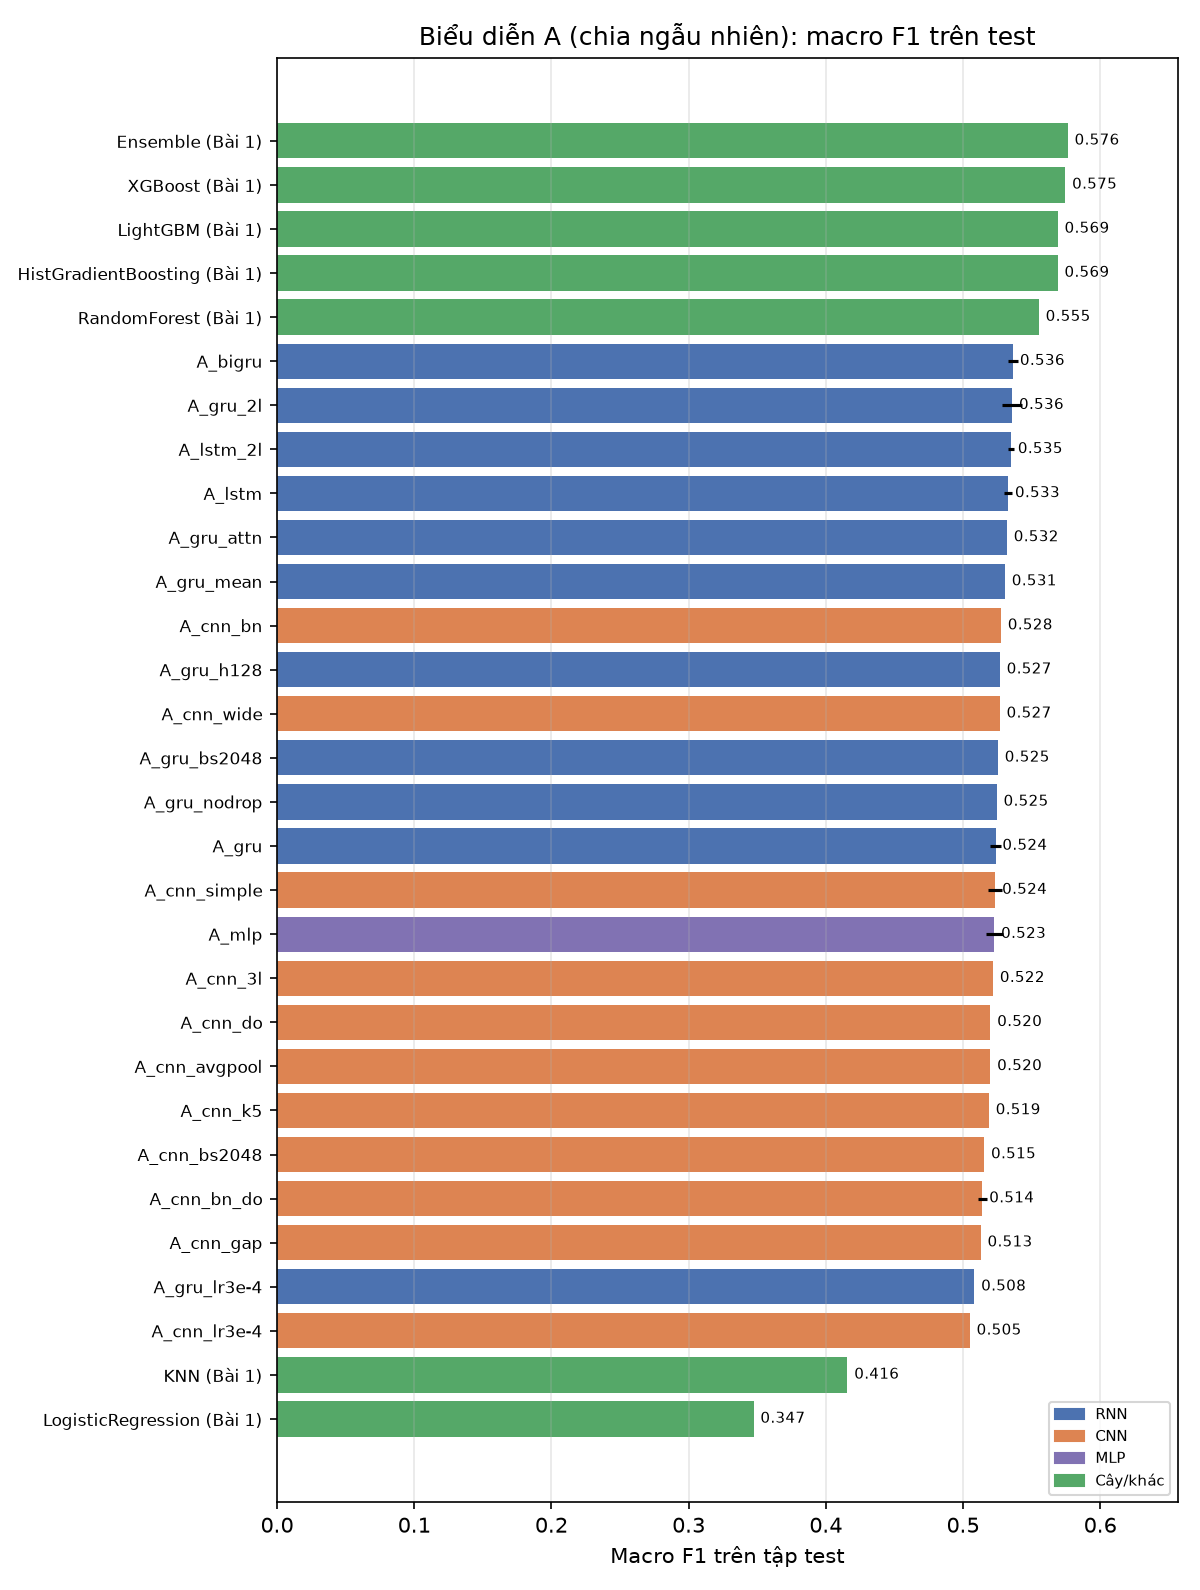

In [13]:
display(Image(FIG / 'bars_A.png'))

In [14]:
# Tốc độ huấn luyện đo riêng (GPU không chia sẻ): giây/epoch trên ~126.500 dòng, batch 512
pd.DataFrame(bench).T.rename(columns={"time_per_epoch_s": "giây/epoch", "n_params": "tham số"}) if bench else "chưa có benchmark.json"

,giây/epoch,tham số
A_lstm,0.4131,27687.0000
A_gru,0.3933,22439.0000
A_lstm_2l,0.6459,60967.0000
A_gru_2l,0.5265,47399.0000
A_bigru,0.4807,42279.0000
A_cnn_simple,0.4329,22663.0000
A_cnn_bn_do,0.5472,22855.0000
A_cnn_3l,0.7341,60103.0000
A_mlp,0.2922,22407.0000
B_lstm,0.9182,31879.0000


## 7. Kết quả biểu diễn B (chia theo địa chỉ) và các thí nghiệm đối chứng

In [15]:
B = summ[summ["group"].isin(["B_group", "A_group", "baseline_group"])]
B[["group"] + cols]

,group,config,arch,lr,batch_size,n_params,best_epoch,epochs,macro_f1,macro_f1_std,n_seeds,binary_f1,accuracy,weighted_f1
0,A_group,A_gru,"GRU 1x64, last",0.0010,512.0000,22439.0000,48.0000,58.0000,0.5289,NaN,1,0.4496,0.9831,0.9842
1,A_group,A_lstm,"LSTM 1x64, last",0.0010,512.0000,27687.0000,40.0000,50.0000,0.5249,NaN,1,0.4496,0.9838,0.9845
2,A_group,A_mlp,"MLP 2x128, do 0.2",0.0010,512.0000,22407.0000,65.0000,75.0000,0.5210,NaN,1,0.4456,0.9843,0.9847
3,A_group,A_cnn_bn_do,"Conv 32-64 k3 maxpool +BN, flatten, do 0.3",0.0010,512.0000,22855.0000,60.0000,70.0000,0.5132,NaN,1,0.4472,0.9839,0.9844
27,B_group,B_cnn_k5,"Conv 32-64 k5 maxpool +BN, gap, do 0.3",0.0010,512.0000,22439.0000,66.0000,76.0000,0.7424,NaN,1,0.7068,0.9925,0.9922
28,B_group,B_cnn_3l,"Conv 32-64-128 k3 maxpool +BN, gap, do 0.3",0.0010,512.0000,45351.0000,32.0000,42.0000,0.7373,NaN,1,0.6973,0.9922,0.9920
29,B_group,B_gru_2l,"GRU 2x64, last",0.0010,512.0000,50567.0000,53.0000,63.0000,0.7349,0.0036,3,0.7140,0.9924,0.9922
30,B_group,B_cnn_bn_do,"Conv 32-64 k3 maxpool +BN, gap, do 0.3",0.0010,512.0000,16295.0000,22.0000,32.0000,0.7313,0.0064,3,0.6932,0.9921,0.9919
31,B_group,B_cnn_cnt,"Conv 32-64 k3 maxpool +BN, gap, do 0.3, +đếm",0.0010,512.0000,16487.0000,20.0000,30.0000,0.7305,NaN,1,0.6994,0.9922,0.9920
32,B_group,B_gru_cnt,"GRU 1x64, last, +đếm",0.0010,512.0000,25799.0000,69.0000,79.0000,0.7219,0.0145,3,0.7011,0.9920,0.9918


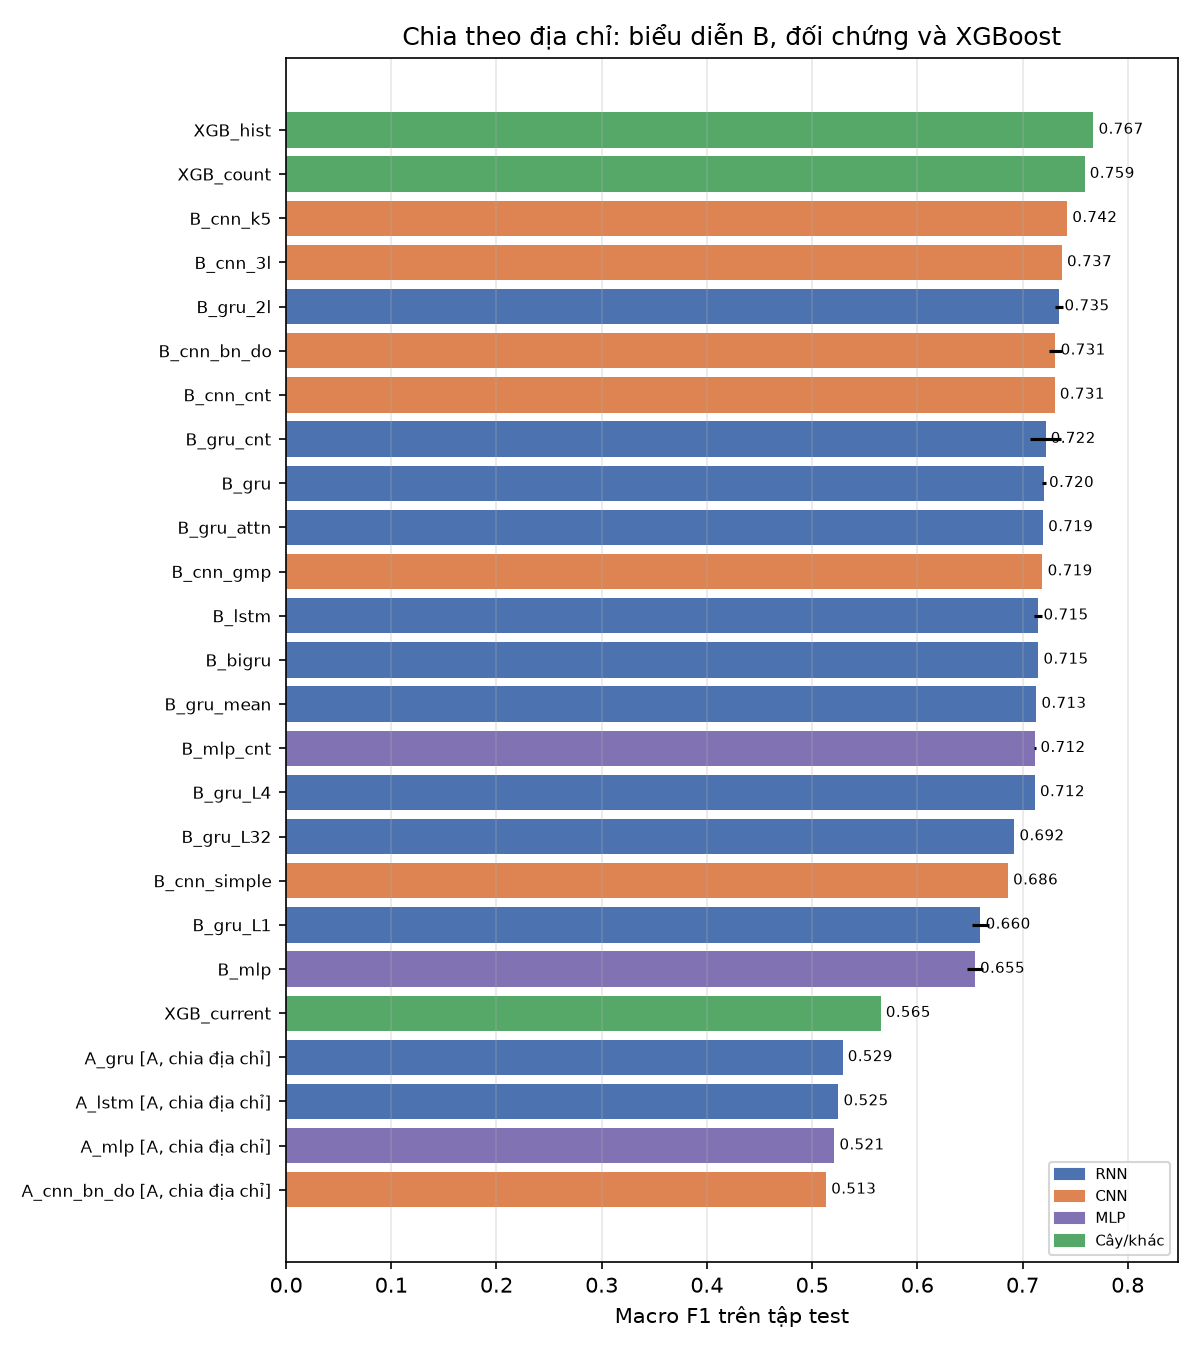

In [16]:
display(Image(FIG / 'bars_B.png'))

In [17]:
# F1 nhị phân trên test theo số lần địa chỉ đã xuất hiện (tính cả ngày hiện tại): mô hình học được gì từ lịch sử?
report.by_len_table(prepB).round(3)

,1,2,3--5,6--15,$>$15
model,,,,,
Số dòng test,526219.0000,19404.0000,17092.0000,13076.0000,7019.0000
\% ransomware,0.7940,2.6440,4.5810,7.5480,20.6870
XGB_current,0.5040,0.4690,0.5400,0.5240,0.4140
B_mlp,0.5590,0.4280,0.6940,0.8330,0.8440
B_gru_L1,0.5450,0.4200,0.6780,0.8310,0.8670
B_gru,0.5490,0.6100,0.7960,0.9170,0.9730
B_cnn_k5,0.5470,0.6250,0.8120,0.9430,0.9480
B_mlp_cnt,0.5530,0.6040,0.7380,0.8540,0.9290
XGB_hist,0.6480,0.6920,0.7930,0.8850,0.9370


## 8. Đường cong huấn luyện — overfitting / underfitting

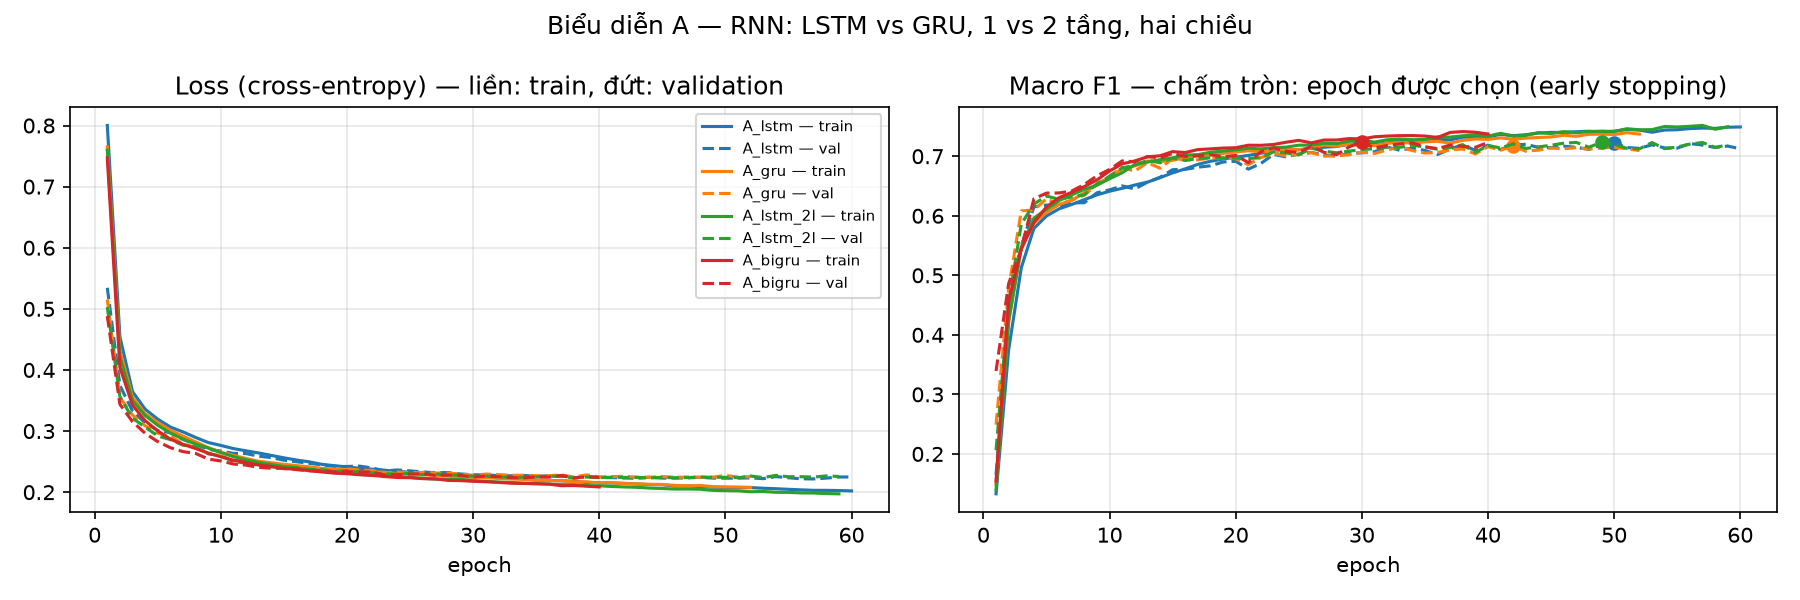

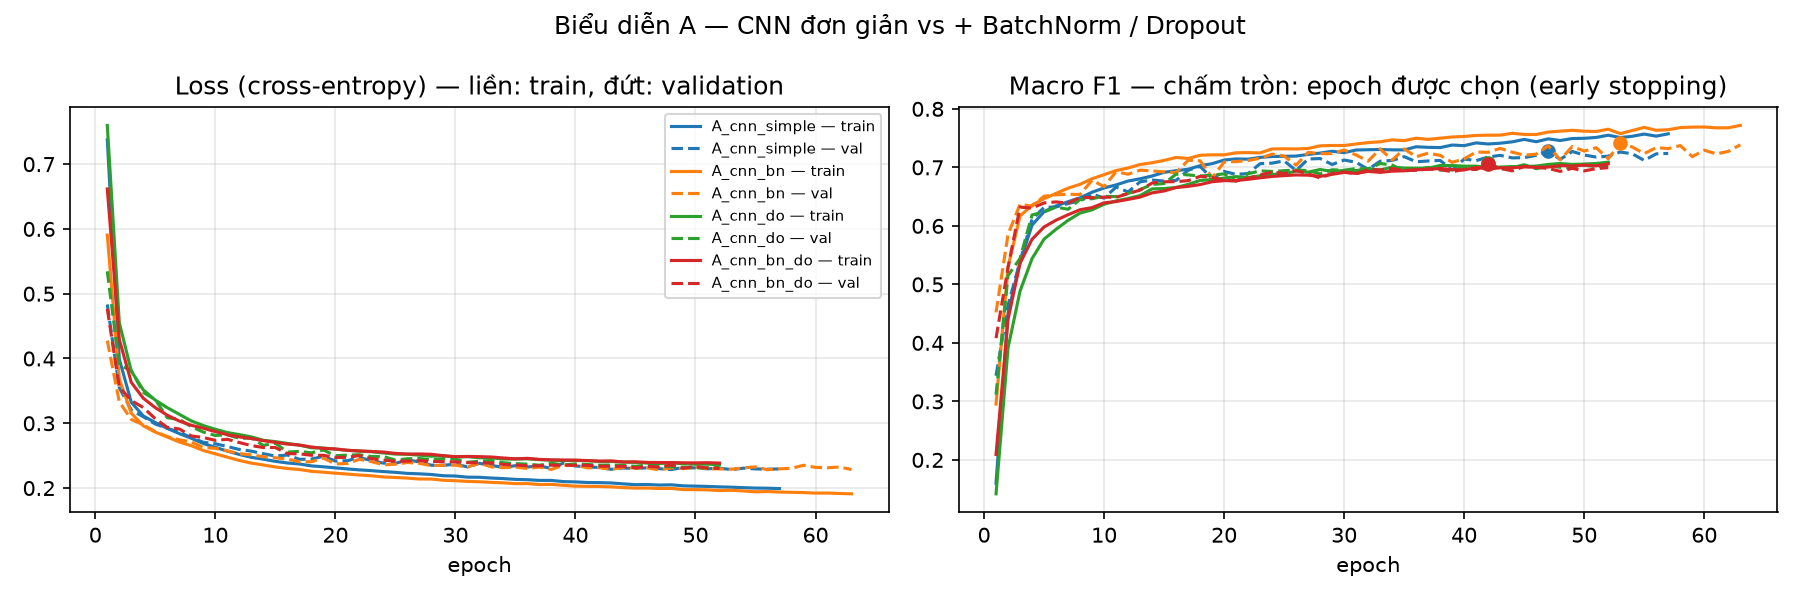

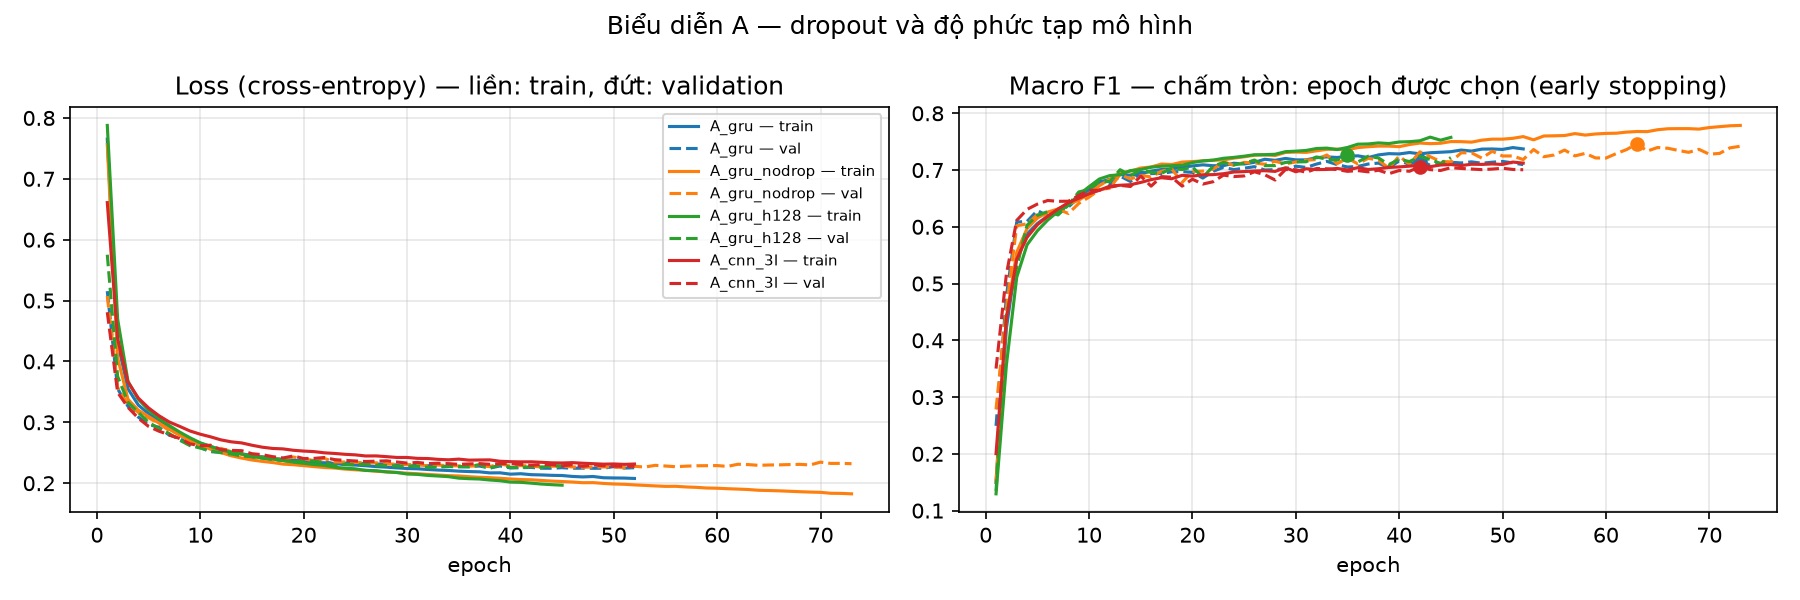

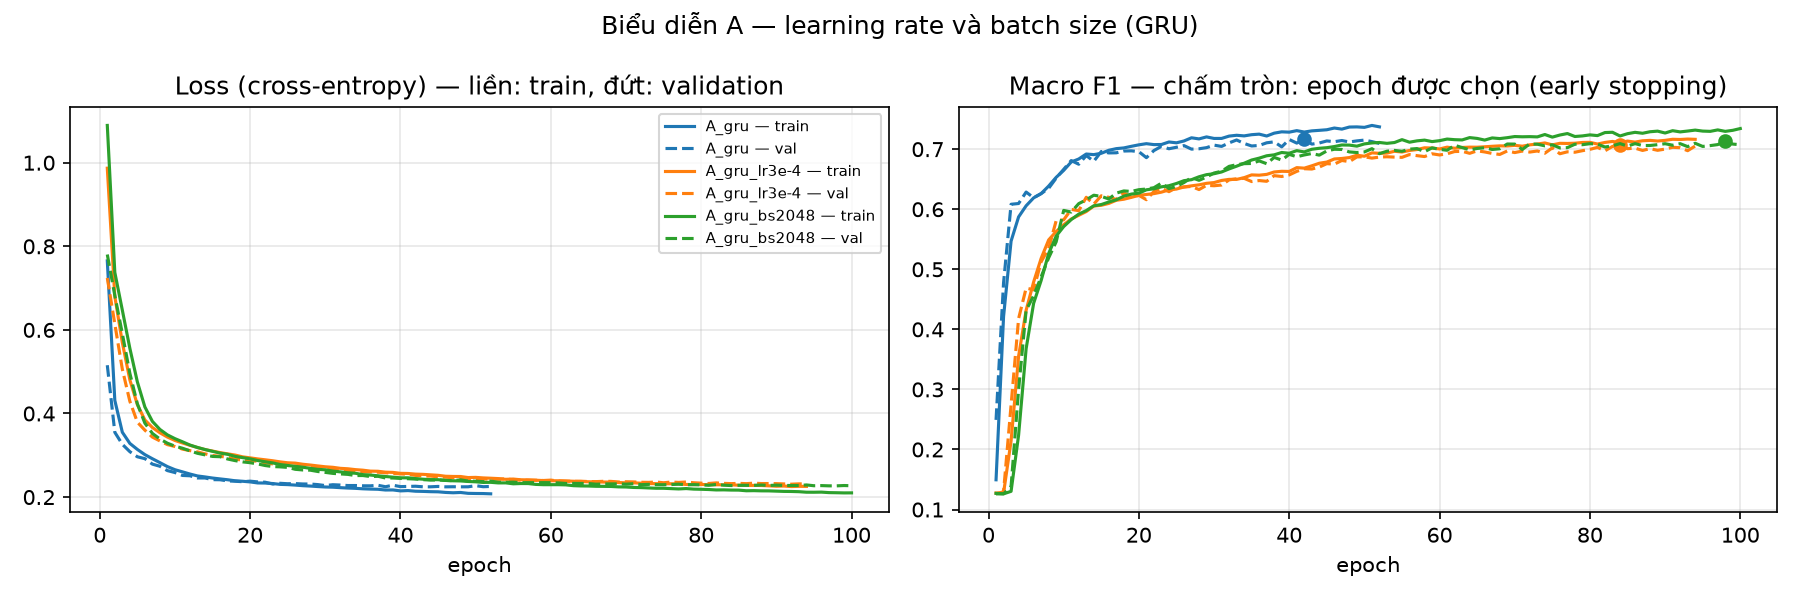

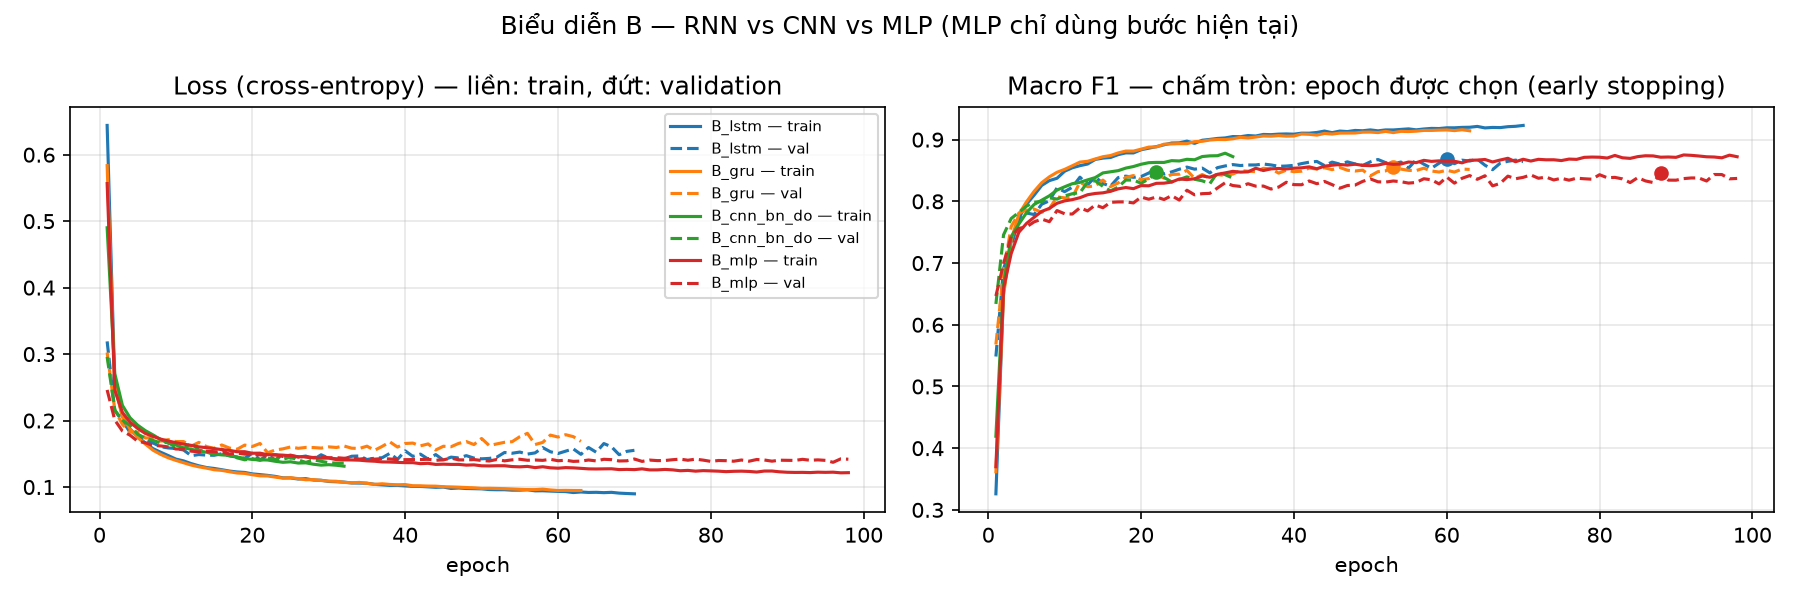

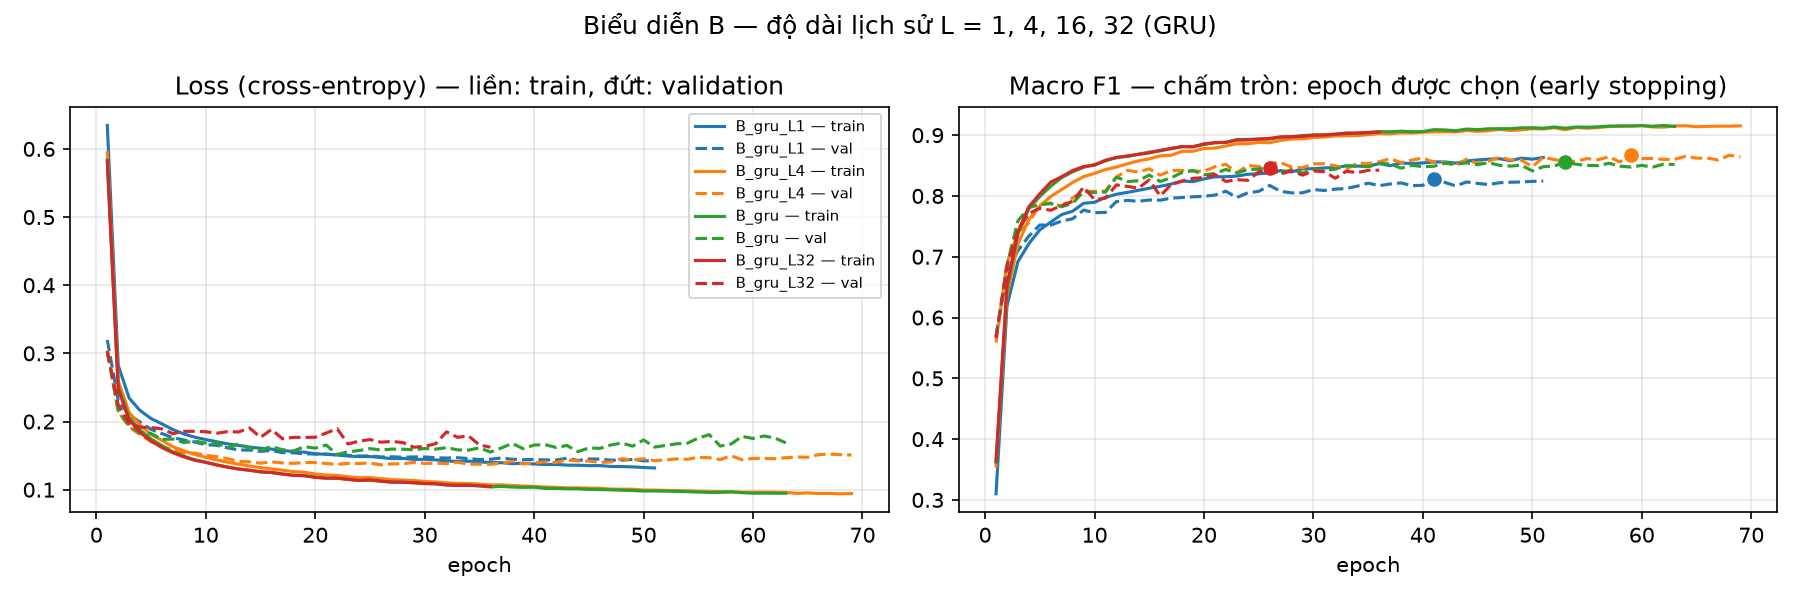

In [18]:
for f in ["curves_A_rnn.png", "curves_A_cnn.png", "curves_A_reg.png", "curves_A_lr.png", "curves_B.png", "curves_B_len.png"]:
    if (FIG / f).exists():
        display(Image(FIG / f))

In [19]:
# Khoảng cách train – val (val_us) ở epoch được chọn và ở epoch cuối — dấu hiệu overfitting / underfitting
g = report.gap_table()
g["chênh F1 @best"] = g["train_f1_best"] - g["val_f1_best"]; g["chênh F1 @cuối"] = g["train_f1_last"] - g["val_f1_last"]
g.round(3)

,group,config,best_epoch,epochs,min_val_loss_epoch,train_f1_best,val_f1_best,train_loss_last,val_loss_last,train_f1_last,val_f1_last,chênh F1 @best,chênh F1 @cuối
0,A_random,A_lstm,50,60,57,0.7420,0.7220,0.2020,0.2250,0.7490,0.7120,0.0200,0.0370
1,A_random,A_gru,42,52,46,0.7290,0.7170,0.2080,0.2250,0.7370,0.7100,0.0120,0.0280
2,A_random,A_gru_nodrop,63,73,51,0.7680,0.7460,0.1830,0.2320,0.7790,0.7420,0.0220,0.0370
3,A_random,A_gru_h128,35,45,38,0.7400,0.7260,0.1970,0.2290,0.7570,0.7220,0.0140,0.0360
4,A_random,A_gru_lr3e-4,84,94,92,0.7110,0.7060,0.2260,0.2310,0.7160,0.7050,0.0040,0.0110
5,A_random,A_gru_bs2048,98,100,98,0.7300,0.7130,0.2100,0.2270,0.7340,0.7070,0.0170,0.0270
6,A_random,A_cnn_simple,47,57,48,0.7490,0.7280,0.1990,0.2300,0.7570,0.7240,0.0210,0.0340
7,A_random,A_cnn_bn,53,63,47,0.7580,0.7410,0.1910,0.2290,0.7720,0.7390,0.0160,0.0330
8,A_random,A_cnn_do,42,52,50,0.6990,0.7080,0.2360,0.2320,0.7090,0.7030,-0.0090,0.0060
9,A_random,A_cnn_bn_do,42,52,52,0.6970,0.7050,0.2390,0.2300,0.7060,0.7000,-0.0080,0.0070


## 9. Ma trận nhầm lẫn & F1 từng lớp

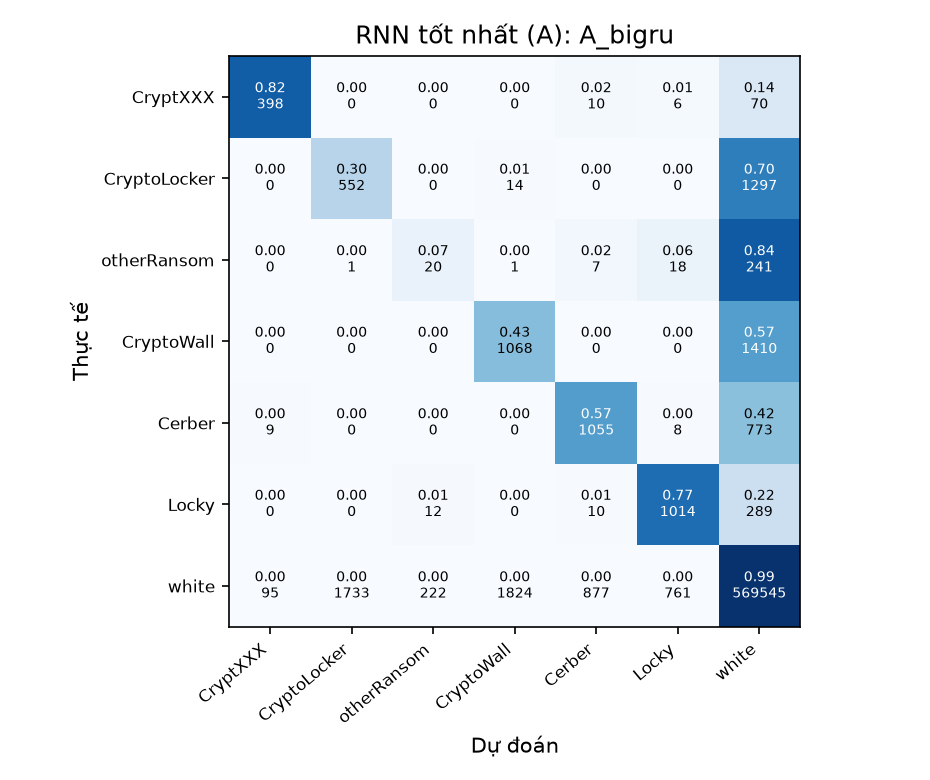

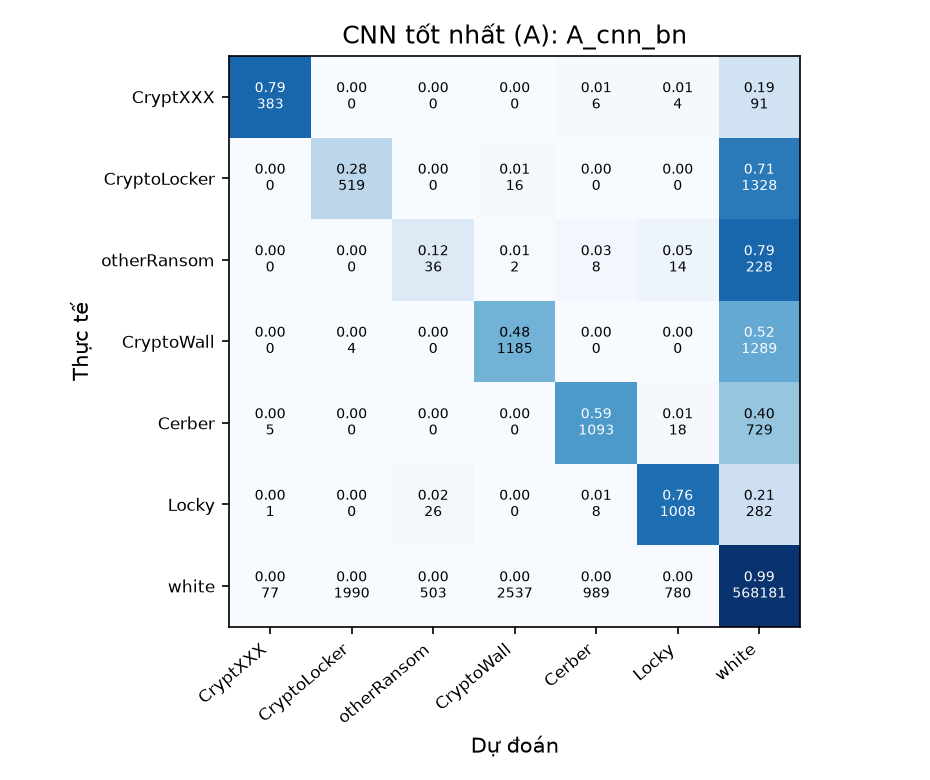

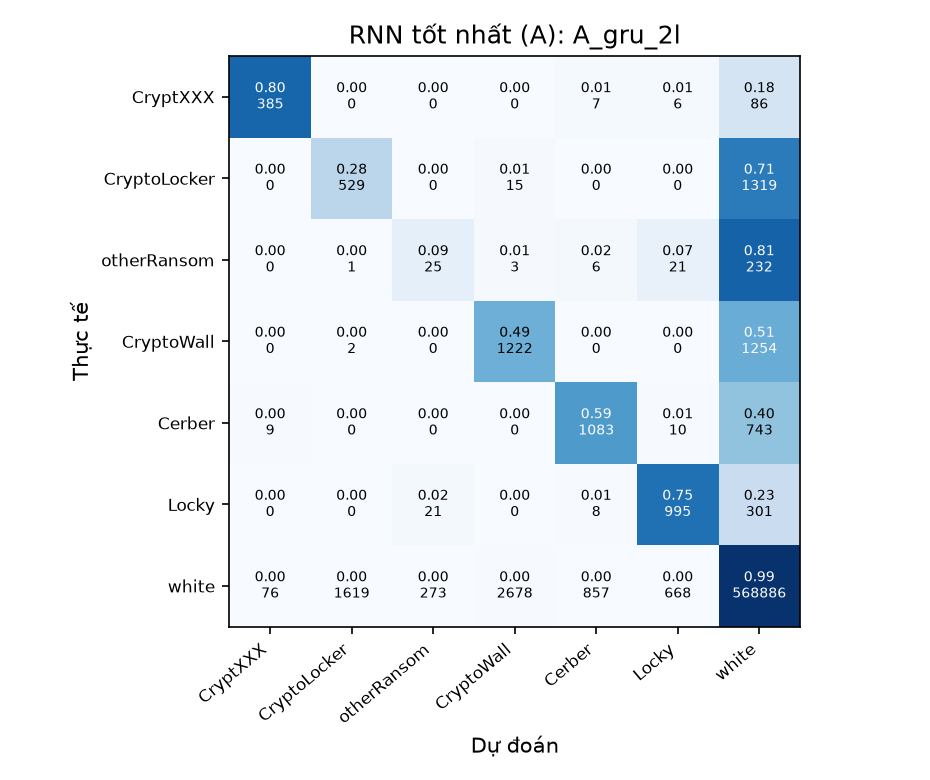

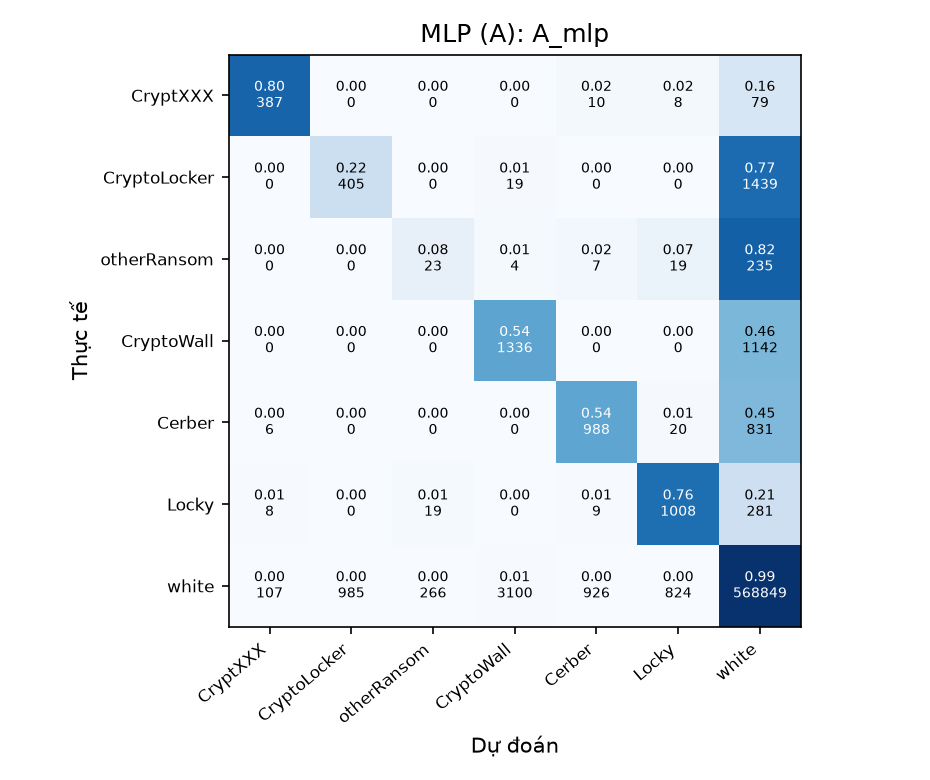

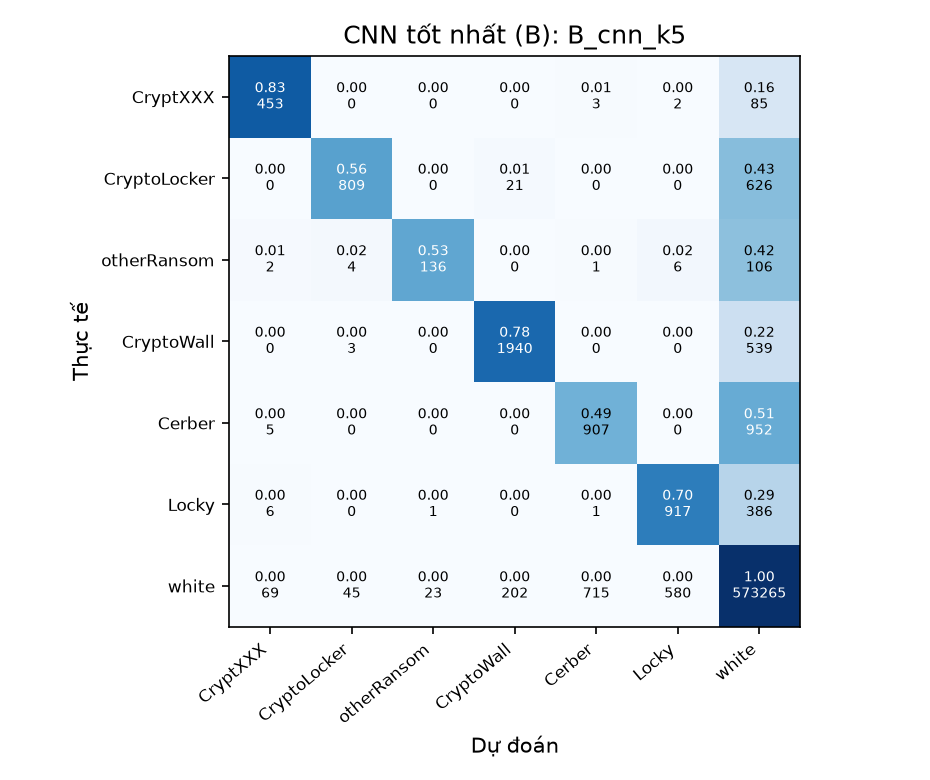

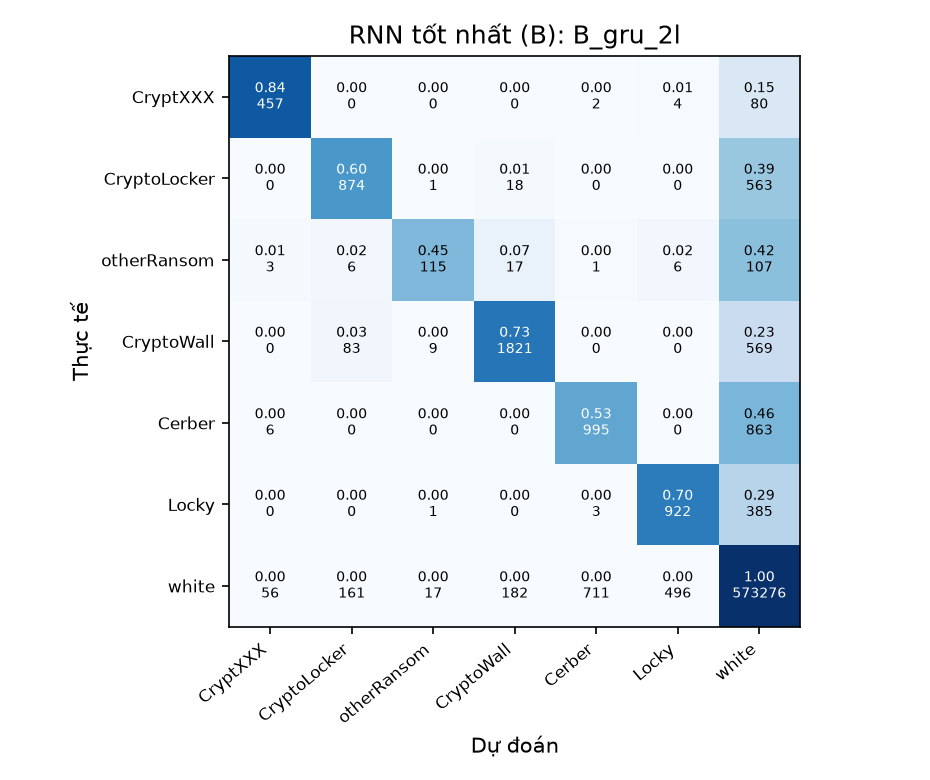

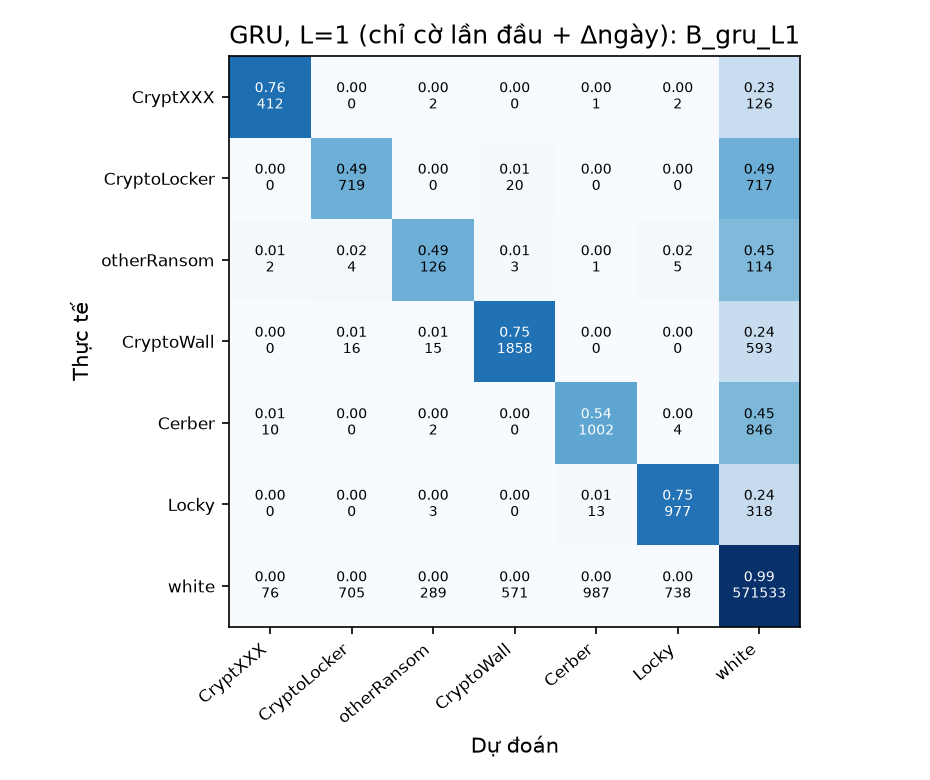

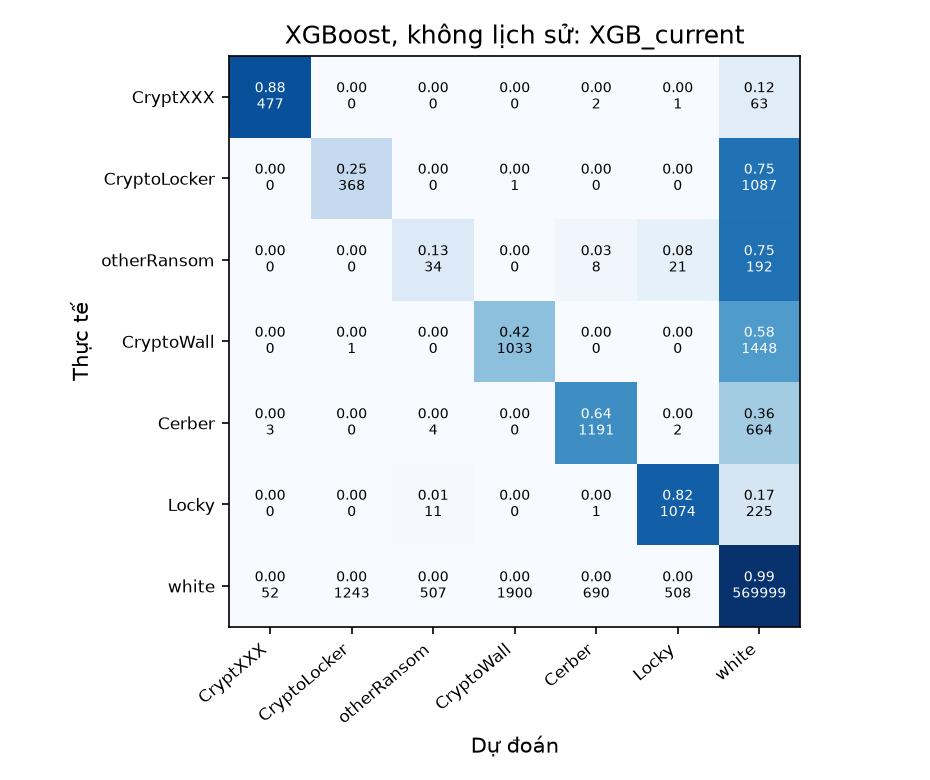

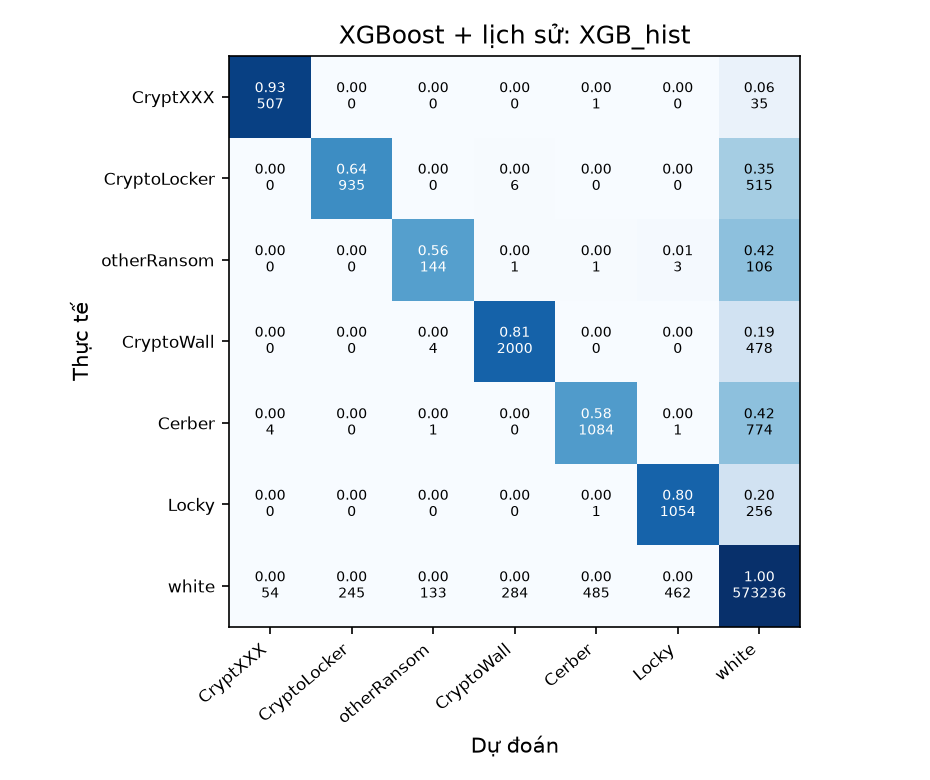

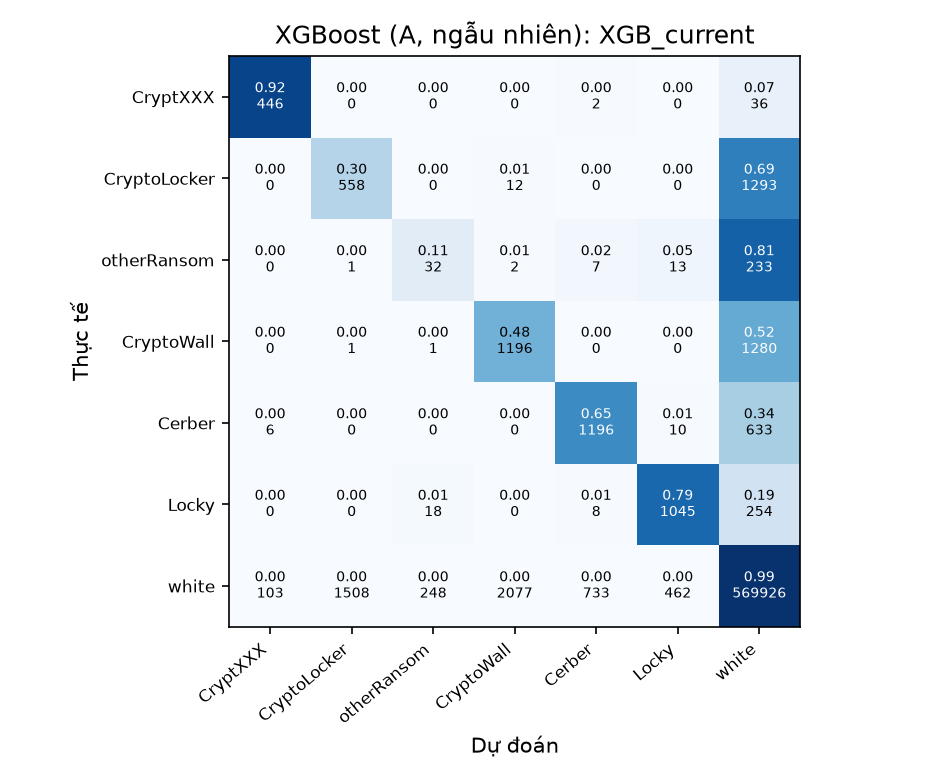

In [20]:
for f in sorted(FIG.glob("cm_*.png")):
    display(Image(f))

In [21]:
pc = []
for _, r in res[res.apply(lambda r: (r["group"], r["name"]) in {(g, n) for g, n, _ in report.key_models(summ)}, axis=1)].iterrows():
    pc.append({"mô hình": f"{r['name']} ({r['split']})", **{report.SHORT[c]: v["f1-score"] for c, v in r["per_class"].items()}})
pd.DataFrame(pc).set_index("mô hình")

,CryptXXX,CryptoLocker,otherRansom,CryptoWall,Cerber,Locky,white
mô hình,,,,,,,
A_bigru (random),0.8073,0.2661,0.0738,0.3967,0.5547,0.6475,0.9916
A_cnn_bn (random),0.8063,0.2372,0.0844,0.3812,0.5536,0.6402,0.9906
A_mlp (random),0.7802,0.2490,0.0772,0.3852,0.5221,0.6292,0.9911
B_cnn_k5 (group),0.8404,0.6983,0.6554,0.8353,0.5196,0.6513,0.9962
B_gru_2l (group),0.8582,0.6775,0.5779,0.8058,0.5565,0.6732,0.9964
B_gru_L1 (group),0.7900,0.4959,0.3642,0.7531,0.5181,0.6434,0.9947
XGB_current (group),0.8874,0.2399,0.0838,0.3815,0.6342,0.7364,0.9925
XGB_hist (group),0.9152,0.7094,0.5363,0.8380,0.6310,0.7446,0.9967
XGB_current (random),0.8585,0.2839,0.1090,0.4149,0.6310,0.7320,0.9923


## 10. Phân tích lỗi & minh hoạ dự đoán

In [22]:
def load_model(group, name):
    ck = torch.load(OUT / group / name / "model.pt", map_location="cpu", weights_only=False)
    m = models.build(ck["cfg"], ck["in_dim"], 27 + 3 * bool(ck["cfg"]["train"].get("side_count")), len(CLASSES), ck["seq_len"])
    m.load_state_dict(ck["state_dict"]); m.eval()
    return m, ck

def predict_rows(group, name, prep, rows):
    m, ck = load_model(group, name)
    b = train.Batcher(prep, ck["cfg"]["rep"], ck["cfg"]["train"].get("history_len"), ck["cfg"]["train"].get("side_count", False))
    with torch.no_grad():
        P = torch.softmax(m(*b(rows)[:3]), 1).numpy()
    S = P * ck["class_weights"]
    return P, S / S.sum(1, keepdims=True)

dev0 = train.DEV
train.DEV = torch.device("cpu")      # suy luận vài dòng trên CPU
rng = np.random.RandomState(0)
te = prepB.idx["test"]
rows = np.concatenate([rng.choice(te[prepB.y[te] == k], 2, replace=False) for k in range(len(CLASSES))])
P, S = predict_rows("B_group", "B_gru", prepB, rows)
demo = df.loc[rows, ["address", "year", "day", "income", "count", "neighbors", "target"]].copy()
demo["số lần trước"] = prepB.n_prev[rows]
demo["dự đoán"] = [CLASSES[k] for k in S.argmax(1)]
demo["độ tin cậy"] = S.max(1)
demo["đúng?"] = demo["dự đoán"] == demo["target"]
demo

,address,year,day,income,count,neighbors,target,số lần trước,dự đoán,độ tin cậy,đúng?
7397,16BPCnWk3yyziGw8XcXKbEnZdhLr6gaeNU,2016,224,120000000.0000,5,2,montrealCryptXXX,0,montrealCryptXXX,0.4337,True
12541,18zb8uE2RAfQySUgq2P7xegGyvxKABfADS,2016,147,219990001.0000,2,2,montrealCryptXXX,3,montrealCryptXXX,0.9993,True
3170,13KQtQ4Y2TCikKW5yVjuFWnzUetUG976FM,2013,329,1415900000.0000,2708,2,montrealCryptoLocker,45,montrealCryptoLocker,1.0000,True
26479,1GSkkYQiRf2QvS59cphT5nFQxyx8jhDZLR,2013,295,38609760.0000,1,2,montrealCryptoLocker,27,montrealCryptoLocker,1.0000,True
21478,1E2T4HuizBkjjV2T1xBUkHg4mzGGq4ZRYv,2015,130,255529278.0000,2,2,otherRansom,23,paduaCryptoWall,0.8478,False
24359,1FjaDRNdp3BzAmHTF3Tc5tbiGCtpYRNZqm,2016,308,50016400.0000,1,1,otherRansom,0,white,0.9935,False
29878,1JRFHsKeLJNk5xditGQNMPGHsjLHHukmdo,2014,186,39108823.0000,585,1,paduaCryptoWall,9,paduaCryptoWall,0.9958,True
22927,1Er8UtELEUgQC21wwZHsDNxhURJB1ZCtuv,2014,90,99750000.0000,1,2,paduaCryptoWall,2,paduaCryptoWall,0.9988,True
18875,1CnFphPKD848fXW7uhHwUVwMAAAoUerELV,2016,116,75000000.0000,1,2,princetonCerber,0,white,0.7542,False
30283,1JxT6A2rrJynYZsJi3HfrhKfAiQXbLCBqo,2016,278,80000000.0000,1,2,princetonCerber,0,princetonCerber,0.8373,True


In [23]:
# Các lỗi phổ biến nhất của mô hình B tốt nhất và của A tốt nhất (cặp thực tế → dự đoán)
def top_errors(group, name, prep, k=8):
    p = np.load(OUT / group / name / "pred_test.npy"); y = prep.y[prep.idx["test"]]
    e = pd.Series([f"{report.SHORT[CLASSES[a]]} → {report.SHORT[CLASSES[b]]}" for a, b in zip(y[p != y], p[p != y])])
    return e.value_counts().head(k).rename(f"{name}: số lỗi")

bestA = A[A["model"] == "rnn"].iloc[0]["config"]
bestB = summ[(summ["group"] == "B_group") & (summ["model"] == "rnn")].iloc[0]["config"]
display(pd.concat([top_errors("A_random", bestA, prepA).reset_index(), top_errors("B_group", bestB, prepB).reset_index()], axis=1))

,index,A_bigru: số lỗi,index,B_gru_2l: số lỗi
0,white → CryptoWall,1824,Cerber → white,863
1,white → CryptoLocker,1733,white → Cerber,711
2,CryptoWall → white,1410,CryptoWall → white,569
3,CryptoLocker → white,1297,CryptoLocker → white,563
4,white → Cerber,877,white → Locky,496
5,Cerber → white,773,Locky → white,385
6,white → Locky,761,white → CryptoWall,182
7,Locky → white,289,white → CryptoLocker,161


In [24]:
# Dòng ransomware bị đoán là white: đặc trưng trông như thế nào so với ransomware được phát hiện đúng?
p = np.load(OUT / "B_group" / bestB / "pred_test.npy"); te = prepB.idx["test"]; y = prepB.y[te]
miss = te[(y != prepB.white) & (p == prepB.white)]; hit = te[(y != prepB.white) & (p == y)]
feat = df[data.NUM[:6]].assign(n_prev=prepB.n_prev)
cmp = pd.DataFrame({"bỏ sót (→ white)": feat.iloc[miss].median(), "phát hiện đúng": feat.iloc[hit].median(),
                    "white (trung vị)": feat.iloc[te[y == prepB.white]].median()})
print(f"Bỏ sót {len(miss):,} / {(y != prepB.white).sum():,} dòng ransomware; theo lớp:")
display(pd.Series([report.SHORT[CLASSES[k]] for k in prepB.y[miss]]).value_counts().to_frame("bỏ sót"))
cmp

Bỏ sót 2,567 / 7,911 dòng ransomware; theo lớp:


,bỏ sót
Cerber,863
CryptoWall,569
CryptoLocker,563
Locky,385
otherRansom,107
CryptXXX,80


,bỏ sót (→ white),phát hiện đúng,white (trung vị)
length,6.0000,6.0000,8.0000
weight,0.3500,0.3125,0.2500
count,1.0000,1.0000,1.0000
looped,0.0000,0.0000,0.0000
neighbors,2.0000,2.0000,2.0000
income,104233818.0000,125000000.0000,200000000.0000
n_prev,0.0000,2.0000,0.0000


In [25]:
# Recall từng họ ransomware: dòng địa chỉ xuất hiện LẦN ĐẦU vs dòng LẶP LẠI (mô hình B tốt nhất vs XGBoost + lịch sử)
first = prepB.n_prev[te] == 0
rows_ = []
for g_, n_ in [("B_group", "B_cnn_k5"), ("B_group", bestB), ("baseline_group", "XGB_hist")]:
    p_ = np.load(OUT / g_ / n_ / "pred_test.npy")
    for k, c in enumerate(CLASSES):
        if k != prepB.white:
            m = y == k
            rows_.append({"mô hình": n_, "lớp": report.SHORT[c], "% lần đầu": 100 * first[m].mean(),
                          "recall lần đầu": (p_[m & first] == k).mean(), "recall lặp lại": (p_[m & ~first] == k).mean()})
pd.DataFrame(rows_).pivot(index="lớp", columns="mô hình", values=["recall lần đầu", "recall lặp lại"]).round(3)

recall lần đầu                   recall lặp lại                  
mô hình            B_cnn_k5 B_gru_2l XGB_hist       B_cnn_k5 B_gru_2l XGB_hist
lớp                                                                           
Cerber               0.4890   0.5340   0.5860         0.1540   0.4620   0.0000
CryptXXX             0.7290   0.7290   0.8980         0.9600   0.9760   0.9760
CryptoLocker         0.0000   0.0000   0.2590         0.6870   0.7420   0.7330
CryptoWall           0.0370   0.0180   0.1120         0.9180   0.8640   0.9320
Locky                0.7020   0.7050   0.8080         0.1430   0.4290   0.1430
otherRansom          0.0000   0.0000   0.1080         0.7160   0.6050   0.7210

In [26]:
train.DEV = dev0

## 11. Kết luận

Chi tiết trong báo cáo (`report/main.pdf`, mục 6–8). Tóm tắt:

- **Biểu diễn A** (11 đặc trưng → chuỗi 11 bước, chia ngẫu nhiên): RNN đạt macro F1 0,51–0,54, CNN 0,50–0,53 — ngang **MLP**
  (0,52) và **thấp hơn XGBoost của Bài 1 (0,575)**. Thứ tự đặc trưng không có ý nghĩa nên cấu trúc chuỗi không giúp; đổi kiến trúc
  (LSTM/GRU, số tầng, hai chiều, attention, BN, kernel…) chỉ thay đổi ≤ 0,03, phần lớn nằm trong dao động seed (≈ 0,005).
- **Biểu diễn B** (lịch sử ≤ 16 lần xuất hiện của địa chỉ, chia theo địa chỉ): macro F1 tăng lên **0,72–0,74**. Mạng nơ-ron tốt nhất là
  **CNN kernel 5 (`B_cnn_k5`, 0,742)**, RNN tốt nhất `B_gru_2l` (0,735 ± 0,004). Lợi ích đến từ các họ dùng lại địa chỉ
  (CryptoLocker 0,26 → 0,70; CryptoWall 0,38 → 0,84; otherRansom 0,08 → 0,66).
- **XGBoost + đặc trưng lịch sử tổng hợp (0,767)** vẫn tốt nhất toàn bộ: RNN/CNN vượt XGBoost trên địa chỉ có lịch sử dài
  (≥ 6 lần xuất hiện) nhưng thua trên địa chỉ mới — nhóm chiếm 90% dòng test và 53% dòng ransomware.
- **Overfitting:** A gần như không overfit (giới hạn do thông tin), điều chuẩn thêm chỉ gây underfit; B overfit rõ hơn
  (val loss tăng từ sớm) và được lợi từ BatchNorm + Dropout (CNN 0,686 → 0,731) và dropout giữa các tầng GRU.
- **Tốc độ** (đo riêng): MLP nhanh nhất; ở A, RNN 1 tầng ≈ CNN (≈ 0,4 s/epoch); ở B, CNN nhanh hơn RNN ≈ 25%,
  Bi-GRU chậm nhất (gấp 2,4 lần GRU).
- Hạn chế: lớp white được lấy mẫu 1.000 dòng/ngày nên tín hiệu "địa chỉ lặp lại" có thể lạc quan hơn thực tế.